## Task 4: Quantization Error at Different Bit Widths

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
tensor = np.array([
    [-1.8, -0.9, 0.0, 0.7, 1.5],
    [-2.4, -0.3, 0.2, 1.1, 2.0]
], dtype=np.float32)

print("Tensor Shape:", tensor.shape)
print(tensor)

Tensor Shape: (2, 5)
[[-1.8 -0.9  0.   0.7  1.5]
 [-2.4 -0.3  0.2  1.1  2. ]]


In [3]:
def quantize_at_bitwidth(tensor, bits):
    """
    Symmetric quantization for arbitrary bit width.

    Returns:
        quantized_tensor
        dequantized_tensor
        scale
        q_min
        q_max
    """

    q_min = -(2 ** (bits - 1)) + 1
    q_max = (2 ** (bits - 1)) - 1

    max_abs = np.max(np.abs(tensor))

    scale = max_abs / q_max

    q = np.round(tensor / scale)

    q = np.clip(q, q_min, q_max)

    q = q.astype(np.int32)

    dq = q.astype(np.float32) * scale

    return q, dq, scale, q_min, q_max

In [4]:
def compute_metrics(original, reconstructed):

    error = original - reconstructed

    abs_error = np.abs(error)

    mae = np.mean(abs_error)

    mse = np.mean(error ** 2)

    max_error = np.max(abs_error)

    return mae, mse, max_error

In [5]:
results = []

bitwidths = [8, 6, 4]

dequantized_results = {}

for bits in bitwidths:

    q, dq, scale, q_min, q_max = (
        quantize_at_bitwidth(
            tensor,
            bits
        )
    )

    mae, mse, max_error = (
        compute_metrics(
            tensor,
            dq
        )
    )

    levels = q_max - q_min + 1

    results.append([
        bits,
        q_min,
        q_max,
        levels,
        scale,
        mae,
        mse,
        max_error
    ])

    dequantized_results[bits] = dq

    print("\n" + "="*60)
    print(f"{bits}-bit Quantization")
    print("="*60)

    print("Scale:")
    print(scale)

    print("\nQuantized:")
    print(q)

    print("\nDequantized:")
    print(dq)

    print("\nMAE:", mae)
    print("MSE:", mse)
    print("Max Error:", max_error)


8-bit Quantization
Scale:
0.018897638

Quantized:
[[ -95  -48    0   37   79]
 [-127  -16   11   58  106]]

Dequantized:
[[-1.7952756  -0.9070866   0.          0.6992126   1.4929134 ]
 [-2.4        -0.3023622   0.20787401  1.096063    2.0031495 ]]

MAE: 0.0037007749
MSE: 2.1638e-05
Max Error: 0.007874012

6-bit Quantization
Scale:
0.077419356

Quantized:
[[-23 -12   0   9  19]
 [-31  -4   3  14  26]]

Dequantized:
[[-1.7806451  -0.92903227  0.          0.6967742   1.4709678 ]
 [-2.4        -0.30967742  0.23225807  1.083871    2.0129032 ]]

MAE: 0.015161285
MSE: 0.00036316324
Max Error: 0.032258064

4-bit Quantization
Scale:
0.34285715

Quantized:
[[-5 -3  0  2  4]
 [-7 -1  1  3  6]]

Dequantized:
[[-1.7142857  -1.0285715   0.          0.6857143   1.3714286 ]
 [-2.4        -0.34285715  0.34285715  1.0285715   2.057143  ]]

MAE: 0.06714286
MSE: 0.0071224505
Max Error: 0.14285715


In [6]:
summary_df = pd.DataFrame(
    results,
    columns=[
        "Bits",
        "q_min",
        "q_max",
        "Levels",
        "Scale",
        "MAE",
        "MSE",
        "Max Error"
    ]
)

summary_df

,Bits,q_min,q_max,Levels,Scale,MAE,MSE,Max Error
0,8,-127,127,255,0.018898,0.003701,0.000022,0.007874
1,6,-31,31,63,0.077419,0.015161,0.000363,0.032258
2,4,-7,7,15,0.342857,0.067143,0.007122,0.142857


### Plot 1 - Original vs Dequantized

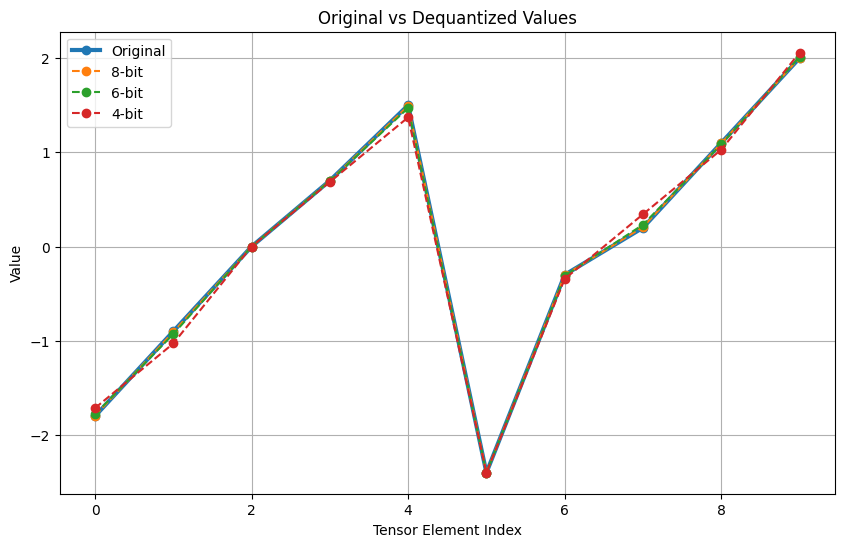

In [7]:
plt.figure(figsize=(10,6))

original = tensor.flatten()

x = np.arange(len(original))

plt.plot(
    x,
    original,
    marker='o',
    linewidth=3,
    label='Original'
)

for bits in [8, 6, 4]:

    plt.plot(
        x,
        dequantized_results[bits].flatten(),
        marker='o',
        linestyle='--',
        label=f'{bits}-bit'
    )

plt.title(
    "Original vs Dequantized Values"
)

plt.xlabel("Tensor Element Index")
plt.ylabel("Value")

plt.grid(True)
plt.legend()

plt.show()

### Plot 2 - MSE vs Bit Width

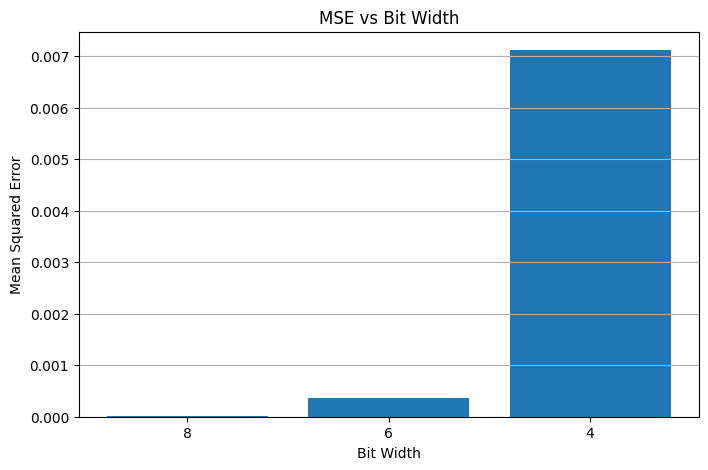

In [8]:
plt.figure(figsize=(8,5))

plt.bar(
    summary_df["Bits"].astype(str),
    summary_df["MSE"]
)

plt.title("MSE vs Bit Width")

plt.xlabel("Bit Width")
plt.ylabel("Mean Squared Error")

plt.grid(axis='y')

plt.show()

### Plot 3 - Max Error vs Bit Width

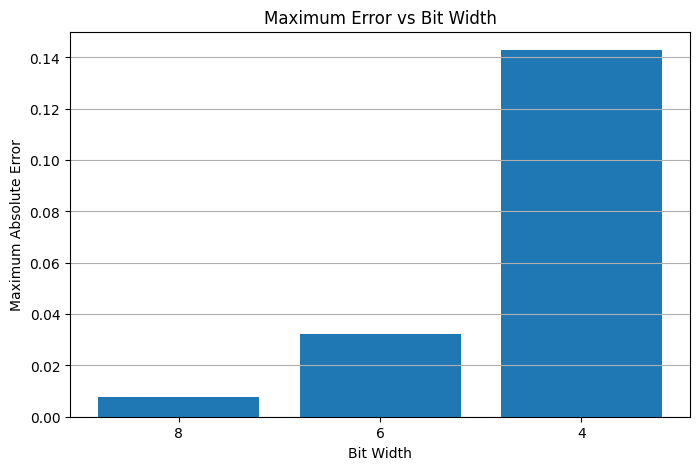

In [9]:
plt.figure(figsize=(8,5))

plt.bar(
    summary_df["Bits"].astype(str),
    summary_df["Max Error"]
)

plt.title(
    "Maximum Error vs Bit Width"
)

plt.xlabel("Bit Width")
plt.ylabel("Maximum Absolute Error")

plt.grid(axis='y')

plt.show()

1. 8-bit quantization has the finest resolution.
   - Smallest scale
   - Lowest MAE
   - Lowest MSE
   - Lowest maximum error

2. 6-bit quantization reduces the number of representable levels
   from 255 to 63.
   - Scale increases
   - Quantization error increases

3. 4-bit quantization has only 15 representable levels.
   - Largest scale
   - Largest quantization error
   - Most visible loss of precision

4. As bit width decreases:
   - Quantization step size increases
   - MSE increases
   - MAE increases
   - Maximum error increases

5. This demonstrates the trade-off:
   Lower precision -> Smaller model size and faster inference
   Higher precision -> Better numerical accuracy